# Notebook 3 - Time Series (TS)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from prophet.make_holidays import make_holidays_df
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# 1. Učitavanje podataka

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mrossini03/cleaned-data/cleaned_data.csv')
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,air_temperature,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,25.0,20.0,0.0,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.0,0,Education,2720,25.0,20.0,0.0,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.0,0,Education,5376,25.0,20.0,0.0,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.0,0,Education,23685,25.0,20.0,0.0,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.0,0,Education,116607,25.0,20.0,0.0,1019.7,0.0,0.0


# 2. Izbacivanje metrika koje nisu električna energija

Prvo izbacujemo sva mjerenja koja nisu električna energija.

In [3]:
df = df[df['meter'] == 0]
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,air_temperature,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0000,0,Education,7432,25.0,20.0,0.0,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.0000,0,Education,2720,25.0,20.0,0.0,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.0000,0,Education,5376,25.0,20.0,0.0,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.0000,0,Education,23685,25.0,20.0,0.0,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.0000,0,Education,116607,25.0,20.0,0.0,1019.7,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32870682,1320,0,2017-12-31 23:00:00,76.7644,14,Entertainment/public assembly,34565,-11.1,-20.6,0.0,1026.2,330.0,2.6
32870683,1321,0,2017-12-31 23:00:00,622.0000,14,Entertainment/public assembly,370024,-11.1,-20.6,0.0,1026.2,330.0,2.6
32870686,1322,0,2017-12-31 23:00:00,134.7052,14,Entertainment/public assembly,166489,-11.1,-20.6,0.0,1026.2,330.0,2.6
32870689,1323,0,2017-12-31 23:00:00,183.0000,14,Office,87200,-11.1,-20.6,0.0,1026.2,330.0,2.6


# 3. Stvaranje agregiranog skupa podataka

Sljedeće, sumiram vrijednosti mjerenja po timestampu te izrađujem skup podataka koji sadrži stupce timestamp i Total_Consumption.

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_agg = df.groupby('timestamp')['meter_reading'].sum().reset_index()
df_agg.columns = ['timestamp', 'Total_Consumption']
df_agg

,timestamp,Total_Consumption
0,2016-01-01 00:00:00,108210.6934
1,2016-01-01 01:00:00,123960.7990
2,2016-01-01 02:00:00,124223.9960
3,2016-01-01 03:00:00,124206.2139
4,2016-01-01 04:00:00,124680.8483
...,...,...
17539,2017-12-31 19:00:00,148927.6931
17540,2017-12-31 20:00:00,148628.8367
17541,2017-12-31 21:00:00,147875.4396
17542,2017-12-31 22:00:00,146719.6292


## 3.1. Vizualizacija skupa podataka

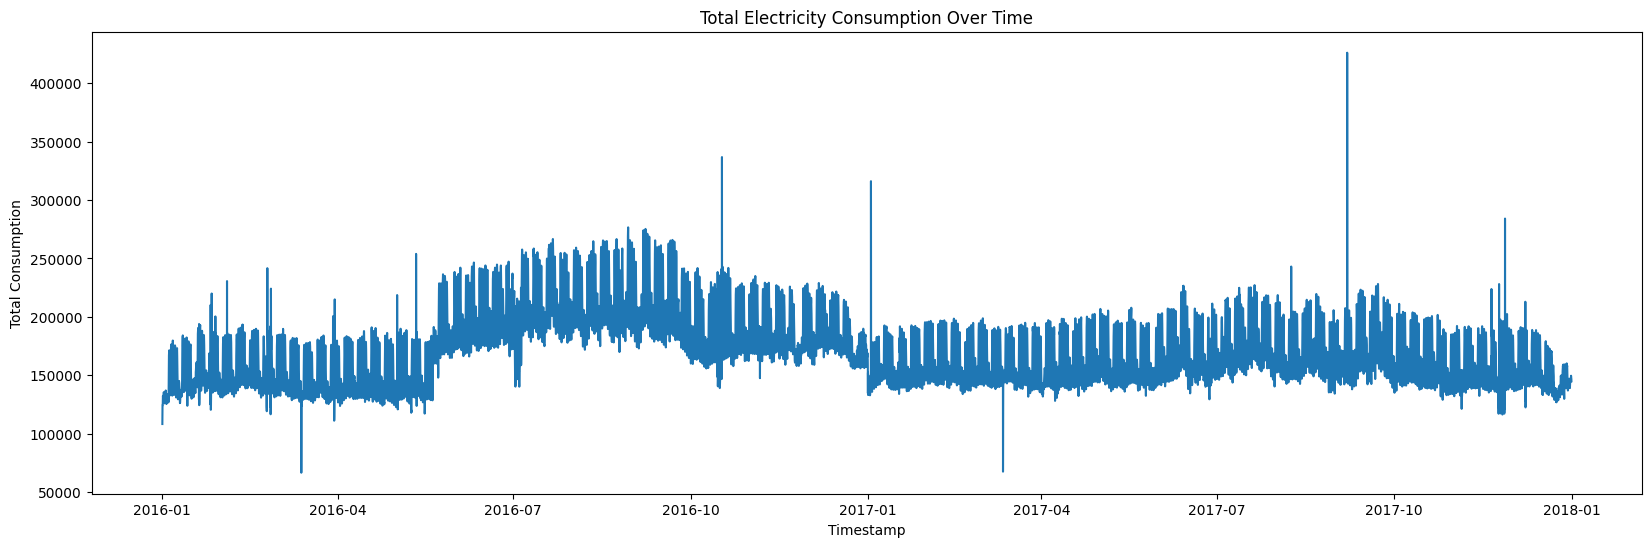

In [5]:
plt.figure(figsize=(20, 6))
plt.plot(df_agg['timestamp'], df_agg['Total_Consumption'])
plt.xlabel('Timestamp')
plt.ylabel('Total Consumption')
plt.title('Total Electricity Consumption Over Time')
plt.show()

Iz vizualizacije može se reći da je trend podataka više manje isti čitavo vrijeme, nema nekog konstantnog rasta ili pada. Primjećuje se određena periodičnost, na prvu djeluje na tjednoj razini (radni dani i vikendi).

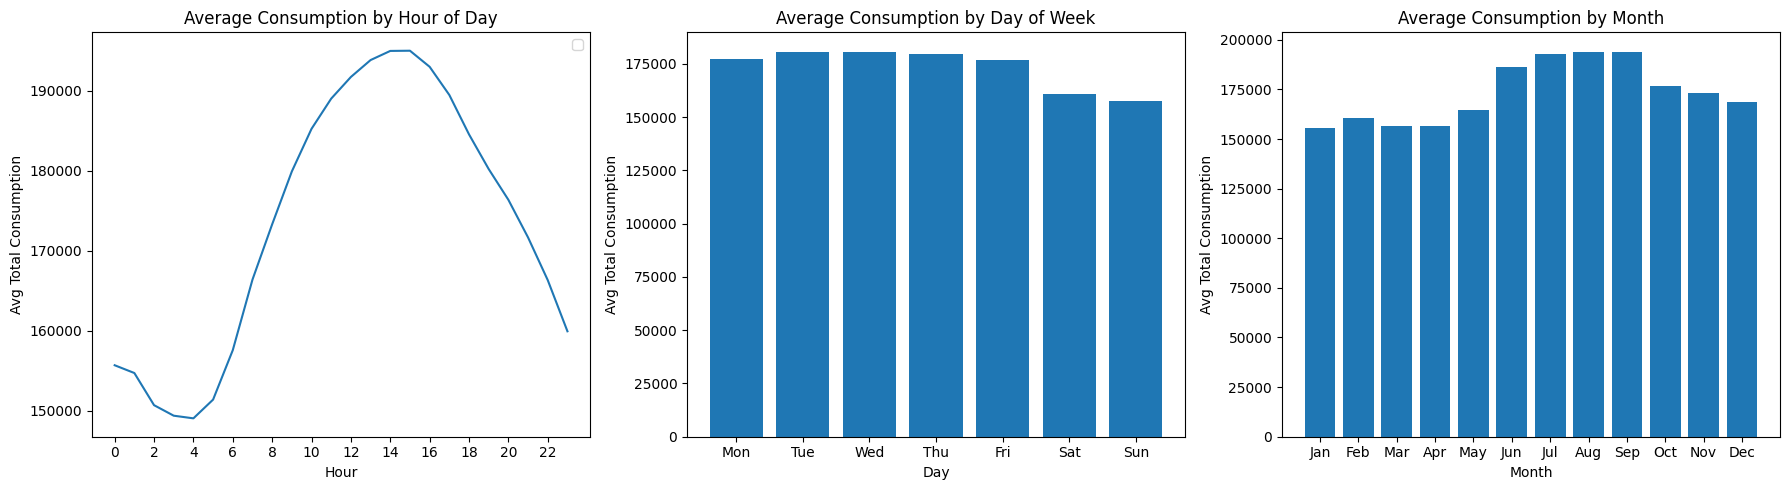

In [6]:
df_total = df_agg.copy()

df_total['hour'] = df_total['timestamp'].dt.hour
df_total['day_of_week'] = df_total['timestamp'].dt.dayofweek
df_total['month'] = df_total['timestamp'].dt.month

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
hourly_mean = df_total.groupby('hour')['Total_Consumption'].mean()
ax.plot(hourly_mean.index, hourly_mean.values)
ax.set_title('Average Consumption by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Total Consumption')
ax.set_xticks(range(0, 24, 2))
ax.legend()

ax = axes[1]
daily_mean = df_total.groupby('day_of_week')['Total_Consumption'].mean()
bars = ax.bar(range(7), daily_mean.values)
ax.set_title('Average Consumption by Day of Week')
ax.set_xlabel('Day')
ax.set_ylabel('Avg Total Consumption')
ax.set_xticks(range(7))
ax.set_xticklabels(days)

ax = axes[2]
monthly_mean = df_total.groupby('month')['Total_Consumption'].mean()
bars = ax.bar(range(1, 13), monthly_mean.values)
ax.set_title('Average Consumption by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Total Consumption')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)

plt.tight_layout()
plt.show()

Očekivano, vidi se da je potrošnja veća tijekom dana nego po noći i isto tako radnim danom nego vikendom. Što se mjeseci tiče, djeluje da je veća potrošnja tijekom toplijih mjeseci.

# 4. Exponential smoothing

Exponential Smoothing je metoda za forecasting vremenskih serija koja daje veću važnost novijim vrijednostima, a starijima manju. Tri glavna parametra su trend, seasonal i seasonal_periods.

## 4.1. Baseline model

Train size: 12280 | Test size: 5264
Baseline RMSE: 18011.65
Baseline MAE: 13694.69


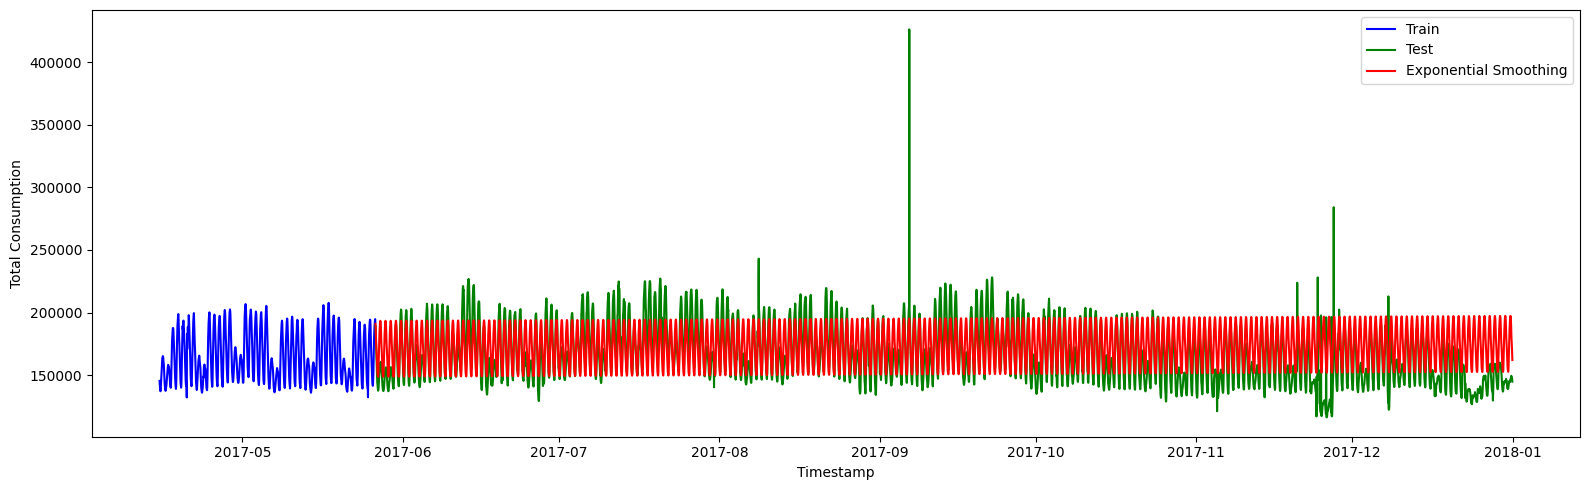

In [7]:
n = len(df_total)
split = int(n * 0.70)

df_total = df_total.set_index('timestamp')
train = df_total['Total_Consumption'].iloc[:split]
test  = df_total['Total_Consumption'].iloc[split:]

print(f"Train size: {len(train)} | Test size: {len(test)}")

model_base = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=24
).fit()

pred_base = model_base.forecast(len(test))

rmse_base = np.sqrt(mean_squared_error(test, pred_base))
mae_base  = mean_absolute_error(test, pred_base)

print(f"Baseline RMSE: {rmse_base:.2f}")
print(f"Baseline MAE: {mae_base:.2f}")

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(train.index[-1000:], train.values[-1000:],
        color='blue', label='Train')
ax.plot(test.index, test.values,
        color='green', label='Test')
ax.plot(test.index, pred_base.values,
        color='red', label='Exponential Smoothing')

ax.set_xlabel('Timestamp')
ax.set_ylabel('Total Consumption')
ax.legend()
plt.tight_layout()
plt.show()

Ovdje je isproban model s parametrima add za trend i seasonal i seasonal_periods = 24 (jedan dan). Nije dao neki bajni rezultat.

## 4.2. Pretraga parametara

Napravit ću svojevrsni grid search kako bih pronašao optimalnu kombinaciju parametara.

In [8]:
results = []

trend_options    = ['add', 'mul', None]
seasonal_options = ['add', 'mul', None]
period_options   = [24, 168]

for trend in trend_options:
    for seasonal in seasonal_options:
        for period in period_options:

            if seasonal == 'mul' and trend is None:
                continue
            if seasonal is None and period:
                if period != period_options[0]:
                    continue

            try:
                model = ExponentialSmoothing(
                    train,
                    trend=trend,
                    seasonal=seasonal,
                    seasonal_periods=period if seasonal else None
                ).fit(optimized=True)

                pred = model.forecast(len(test))
                rmse = np.sqrt(mean_squared_error(test, pred))
                mae  = mean_absolute_error(test, pred)

                results.append({
                    'trend': trend,
                    'seasonal': seasonal,
                    'period': period if seasonal else '-',
                    'RMSE': round(rmse, 2),
                    'MAE': round(mae, 2)
                })

            except Exception as e:
                pass

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
print(results_df.to_string(index=False))

trend seasonal period      RMSE       MAE
 None      add    168  13190.65   9696.84
 None      add     24  16915.41  12679.86
  mul      add    168  17346.28  14908.95
  add      add     24  18011.65  13694.69
  add      mul    168  20834.60  15545.89
  mul      mul    168  27605.98  24965.61
  add      add    168  33920.36  31137.38
 None     None      -  34198.85  29450.58
  mul      mul     24  82022.80  75052.52
  mul      add     24  92851.87  85928.44
  add      mul     24 129047.10 108449.38
  mul     None      - 132133.67 123864.15
  add     None      - 168496.80 144196.27


Najbolja kombinacija je trend = None, seasonal = add i period = 168 (jedan tjedan). To ima smisla jer trend = None nam govori da nema nekog konstantnog porasta ili pada u podacima, a period od tjedan dana nam govori da postoji periodičnost na tjednoj razini, što se vidi u odnosu potrošnje radnim danima i vikendom.

## 4.3. Najbolji model

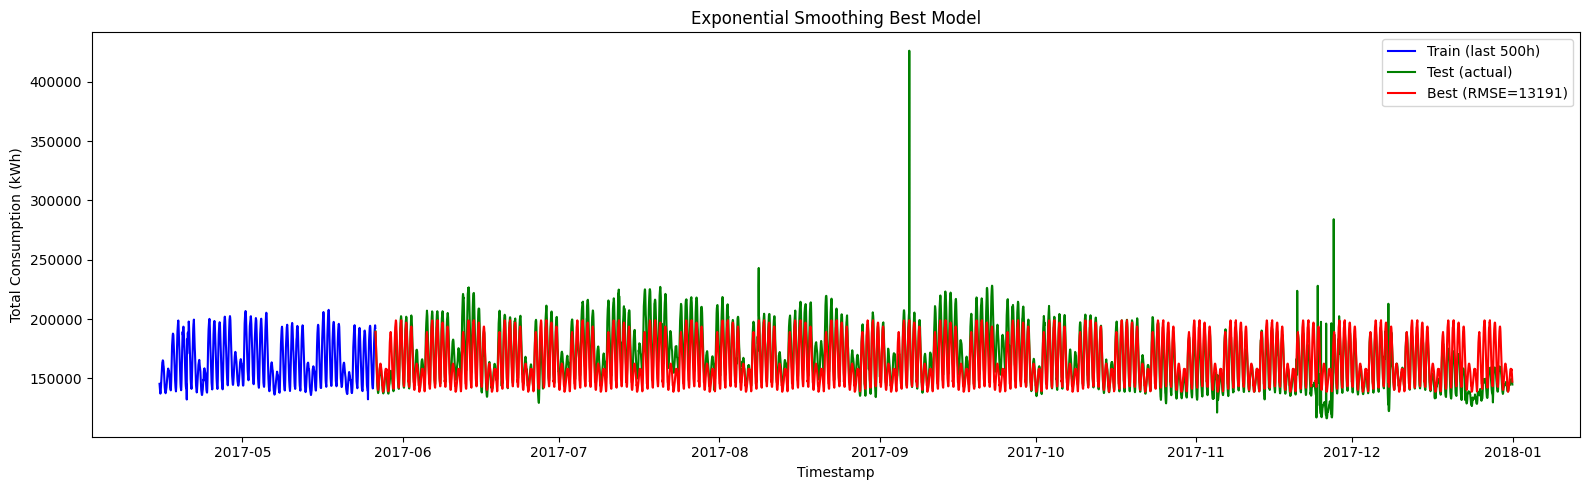

In [9]:
best = results_df.iloc[0]
model_best = ExponentialSmoothing(
    train,
    trend=best['trend'],
    seasonal=best['seasonal'],
    seasonal_periods=int(best['period']) if best['period'] != '-' else None
).fit(optimized=True)

pred_best = model_best.forecast(len(test))

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(train.index[-1000:], train.values[-1000:],
        color='blue', label='Train (last 500h)')
ax.plot(test.index, test.values,
        color='green', label='Test (actual)')
ax.plot(test.index, pred_best.values,
        color='red', label=f'Best (RMSE={best["RMSE"]:.0f})')

ax.set_title('Exponential Smoothing Best Model')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Total Consumption (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

Dobiveni rezultat malo bolje prati prave podatke, ali i dalje je poprilično limitiran.

# 5. ARIMA

ARIMA (Auto-Regressive Integrated Moving Average) je statistički parametarski model namijenjen za analizu i predviđanje vremenskih nizova. Ima tri glavna parametra: p koji predstavlja autoregresiju, d za diferenciranje i parametar q za pomični prosjek.

## 5.1. Izrada funkcija

In [10]:
def fit_arima(order):
    model = ARIMA(train, order=order).fit()
    forecast = model.get_forecast(steps=len(test))
    pred = forecast.predicted_mean
    ci   = forecast.conf_int()
    rmse = np.sqrt(mean_squared_error(test, pred))
    mae  = mean_absolute_error(test, pred)
    return pred, ci, rmse, mae

def fit_sarima(order, seasonal_order):
    model = SARIMAX(train, order=order, seasonal_order=seasonal_order).fit(disp=False)
    forecast = model.get_forecast(steps=len(test))
    pred = forecast.predicted_mean
    ci   = forecast.conf_int()
    rmse = np.sqrt(mean_squared_error(test, pred))
    mae  = mean_absolute_error(test, pred)
    return pred, ci, rmse, mae

def plot_forecast(pred, ci, title):
    plt.figure(figsize=(14, 4))
    plt.plot(train.index[-1000:], train.values[-1000:], label='Train')
    plt.plot(test.index, test.values, label='Test')
    plt.plot(test.index, pred.values, linestyle='--', label='Forecast')
    if ci is not None:
        plt.fill_between(test.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2)
    
    ymin = train.values[-1000:].min() * 0.8
    ymax = train.values[-1000:].max() * 1.2
    plt.ylim(ymin, ymax)
    
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 5.2. Baseline ARIMA

ARIMA(1,1,1) - RMSE: 22985.49 | MAE: 18937.76


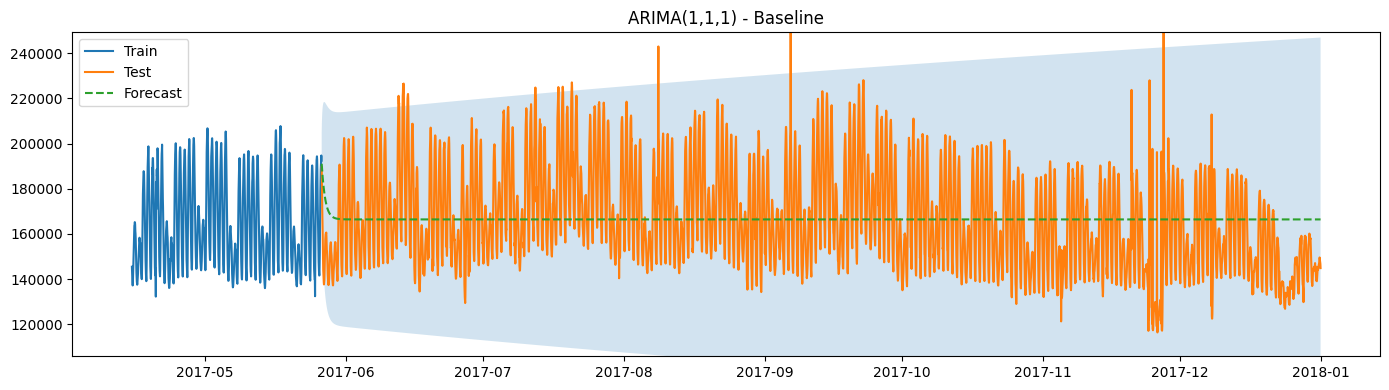

In [11]:
pred, ci, rmse, mae = fit_arima((1, 1, 1))
print(f"ARIMA(1,1,1) - RMSE: {rmse:.2f} | MAE: {mae:.2f}")
plot_forecast(pred, ci, 'ARIMA(1,1,1) - Baseline')

results = [{'model': 'ARIMA(1,1,1)', 'RMSE': round(rmse,2), 'MAE': round(mae,2)}]

Isproban je ARIMA model za parametre p = 1, d = 1, q = 1. Interval pouzdanosti nam govori za koje područje je model poprilično siguran da će stvarna vrijednost pasti unutar njega u svakom trenutku. Budući da je on ovdje jako širok, ne odaje nam previše informacija.

## 5.3. Isprobavanje parametra p

Isprobat ću nekoliko različitih parametara p, dok su druga dva parametra postavljena na nula.

ARIMA(1,0,0) - RMSE: 24725.51 | MAE: 21138.12
ARIMA(2,0,0) - RMSE: 24684.03 | MAE: 21106.86
ARIMA(5,0,0) - RMSE: 24615.64 | MAE: 21051.62
ARIMA(10,0,0) - RMSE: 24589.43 | MAE: 21027.71


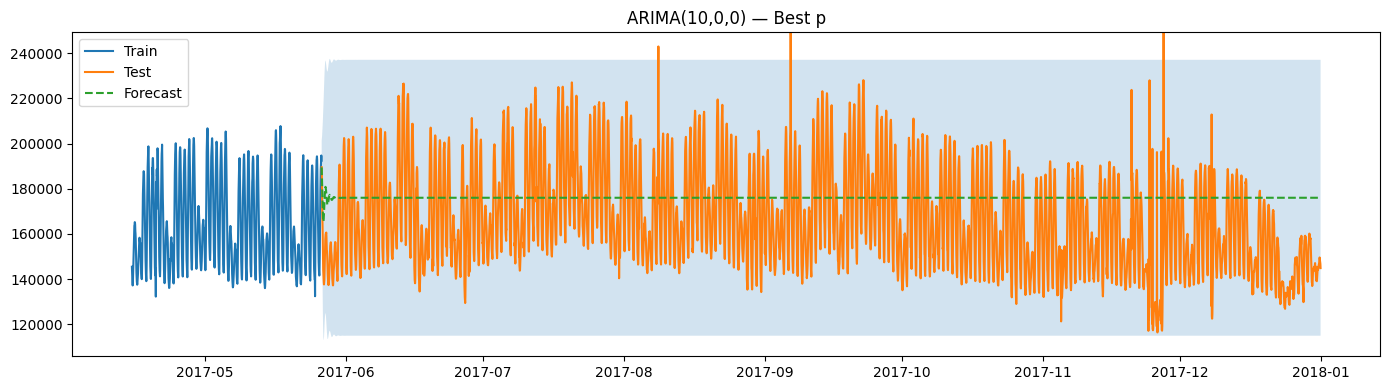

In [12]:
best_rmse, best_pred, best_ci, best_p = np.inf, None, None, None

for p in [1, 2, 5, 10]:
    pred, ci, rmse, mae = fit_arima((p, 0, 0))
    print(f"ARIMA({p},0,0) - RMSE: {rmse:.2f} | MAE: {mae:.2f}")
    results.append({'model': f'ARIMA({p},0,0)', 'RMSE': round(rmse,2), 'MAE': round(mae,2)})
    if rmse < best_rmse:
        best_rmse, best_pred, best_ci, best_p = rmse, pred, ci, p

plot_forecast(best_pred, best_ci, f'ARIMA({best_p},0,0) — Best p')

Povećavanje parametra p blago je smanjilo RMSE, ali pogreške modela i dalje su visoke.

## 5.4. Isprobavanje parametra q

ARIMA(0,0,1) - RMSE: 24606.50 | MAE: 21042.13
ARIMA(0,0,2) - RMSE: 24606.28 | MAE: 21041.30
ARIMA(0,0,5) - RMSE: 24606.20 | MAE: 21040.36
ARIMA(0,0,10) - RMSE: 24607.76 | MAE: 21043.21


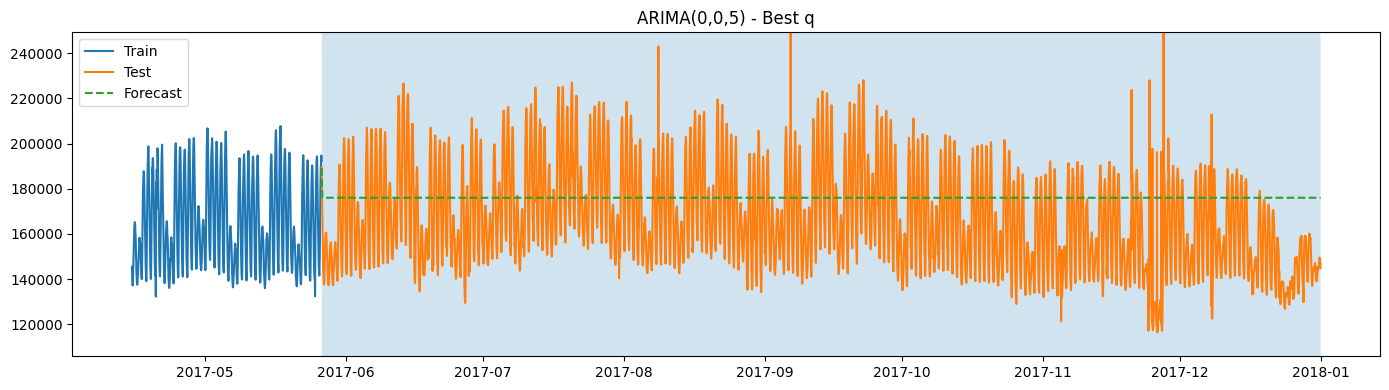

In [13]:
best_rmse, best_pred, best_ci, best_q = np.inf, None, None, None

for q in [1, 2, 5, 10]:
    pred, ci, rmse, mae = fit_arima((0, 0, q))
    print(f"ARIMA(0,0,{q}) - RMSE: {rmse:.2f} | MAE: {mae:.2f}")
    results.append({'model': f'ARIMA(0,0,{q})', 'RMSE': round(rmse,2), 'MAE': round(mae,2)})
    if rmse < best_rmse:
        best_rmse, best_pred, best_ci, best_q = rmse, pred, ci, q

plot_forecast(best_pred, best_ci, f'ARIMA(0,0,{best_q}) - Best q')

Slična priča kao za parametar p, i promjena parametra q nije donijela neke spektakularne rezultate.

## 5.5. Isprobavanje parametra d

ARIMA(0,1,0) - RMSE: 34198.85 | MAE: 29450.58
ARIMA(0,2,0) - RMSE: 7015605.85 | MAE: 6072624.41


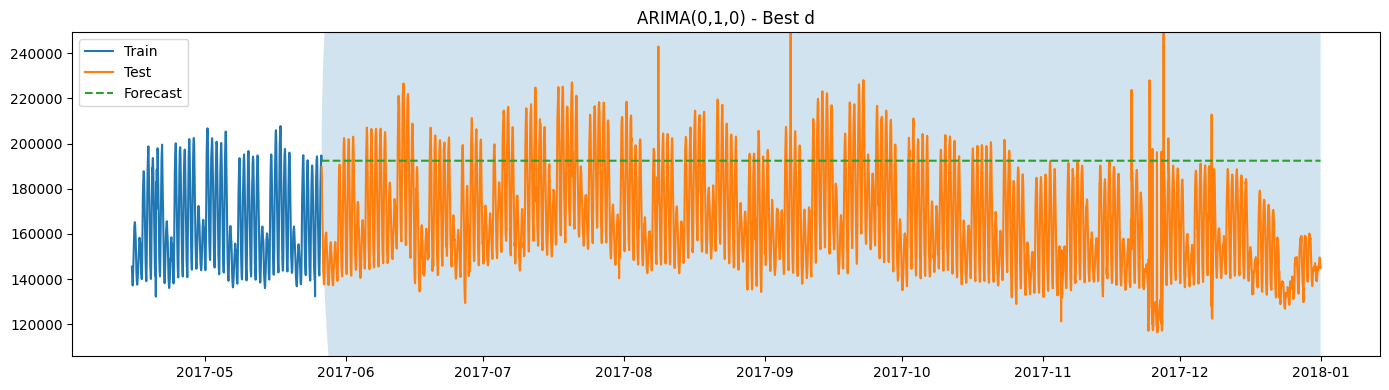

In [14]:
best_rmse, best_pred, best_ci, best_d = np.inf, None, None, None

for d in [1, 2]:
    pred, ci, rmse, mae = fit_arima((0, d, 0))
    print(f"ARIMA(0,{d},0) - RMSE: {rmse:.2f} | MAE: {mae:.2f}")
    results.append({'model': f'ARIMA(0,{d},0)', 'RMSE': round(rmse,2), 'MAE': round(mae,2)})
    if rmse < best_rmse:
        best_rmse, best_pred, best_ci, best_d = rmse, pred, ci, d

plot_forecast(best_pred, best_ci, f'ARIMA(0,{best_d},0) - Best d')

Parametar d = 1 daje značajno bolji rezultat nego d = 2, ali opet dosta lošije nego ostali isprobani modeli.

## 5.6. Isprobavanje više parametara odjednom

ARIMA(1,0,1) — RMSE: 24702.49 | MAE: 21120.91
ARIMA(1,0,2) — RMSE: 24681.94 | MAE: 21105.42
ARIMA(1,0,5) — RMSE: 24651.24 | MAE: 21081.60
ARIMA(1,1,1) — RMSE: 22985.49 | MAE: 18937.76
ARIMA(1,1,2) — RMSE: 34023.67 | MAE: 29291.15
ARIMA(1,1,5) — RMSE: 29992.24 | MAE: 25684.25
ARIMA(2,0,1) — RMSE: 24625.43 | MAE: 21059.77
ARIMA(2,0,2) — RMSE: 24612.98 | MAE: 21049.75
ARIMA(2,0,5) — RMSE: 24600.16 | MAE: 21038.49
ARIMA(2,1,1) — RMSE: 34856.03 | MAE: 30049.68
ARIMA(2,1,2) — RMSE: 27967.76 | MAE: 23948.40
ARIMA(2,1,5) — RMSE: 22614.65 | MAE: 18758.36
ARIMA(5,0,1) — RMSE: 24616.15 | MAE: 21052.20
ARIMA(5,0,2) — RMSE: 24616.19 | MAE: 21052.26
ARIMA(5,0,5) — RMSE: 24613.06 | MAE: 21049.87
ARIMA(5,1,1) — RMSE: 23046.86 | MAE: 19333.40
ARIMA(5,1,5) — RMSE: 22551.56 | MAE: 18826.91


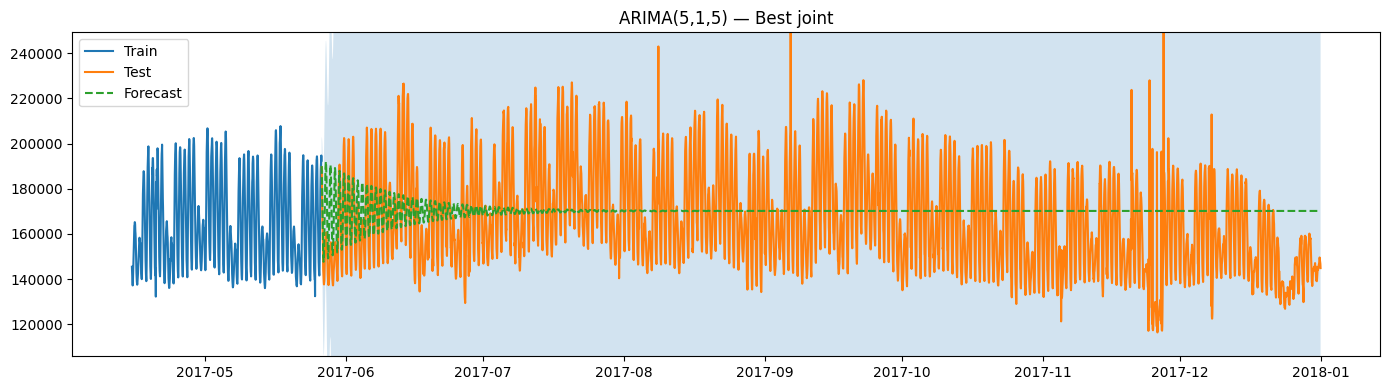

In [15]:
best_rmse, best_pred, best_ci, best_order = np.inf, None, None, None

for p in [1, 2, 5]:
    for d in [0, 1]:
        for q in [1, 2, 5]:
            try:
                pred, ci, rmse, mae = fit_arima((p, d, q))
                print(f"ARIMA({p},{d},{q}) — RMSE: {rmse:.2f} | MAE: {mae:.2f}")
                results.append({'model': f'ARIMA({p},{d},{q})', 'RMSE': round(rmse,2), 'MAE': round(mae,2)})
                if rmse < best_rmse:
                    best_rmse, best_pred, best_ci, best_order = rmse, pred, ci, (p,d,q)
            except:
                pass

p,d,q = best_order
plot_forecast(best_pred, best_ci, f'ARIMA({p},{d},{q}) — Best joint')

Od svih raznih isprobanih kombinacija, najbolja je ispala p = 5, d = 1, q = 5. No, greška je i dalje slična kao i na početku. Djeluje da model ARIMA nije dovoljno dobar.

## 5.7. SARIMA

Seasonal ARIMA uzima u obzir sezonalnost i ima 4 dodatna parametra: P za sezonalni stupanj AR, D za
sezonalni stupanj razlike, Q za sezonalni stupanj pomičnog prosjeka i m za broj točaka u
jednom periodu.

SARIMA(5, 1, 5)x(1,0,0,24) — RMSE: 22394.50 | MAE: 18670.29
SARIMA(5, 1, 5)x(1,0,1,24) — RMSE: 24163.70 | MAE: 19194.90


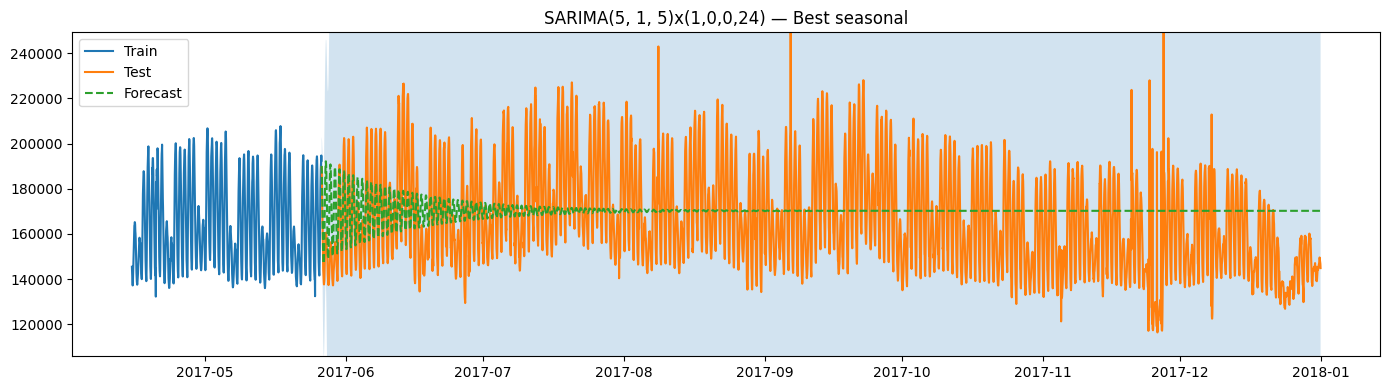

In [16]:
best_rmse, best_pred, best_ci, best_s_order = np.inf, None, None, None

for P, D, Q in [(1,0,0), (1,0,1)]:
    try:
        pred, ci, rmse, mae = fit_sarima(best_order, (P, D, Q, 24))
        label = f'SARIMA{best_order}x({P},{D},{Q},24)'
        print(f"{label} — RMSE: {rmse:.2f} | MAE: {mae:.2f}")
        results.append({'model': label, 'RMSE': round(rmse,2), 'MAE': round(mae,2)})
        if rmse < best_rmse:
            best_rmse, best_pred, best_ci, best_s_order = rmse, pred, ci, (P,D,Q,24)
    except Exception as e:
        print(f"Failed ({P},{D},{Q}): {e}")

P,D,Q,s = best_s_order
plot_forecast(best_pred, best_ci, f'SARIMA{best_order}x({P},{D},{Q},{s}) — Best seasonal')

Isprobana je nadogradnja na najbolji ARIMA model, ostvareno je blago poboljšanje, ali i dalje bez nekog velikog napretka. Da je manje vremenski zahtjevan, isproban bi bio parametar m = 168 koji bi moguće ostvario neki bolji rezultat.

# 6. Prophet

PROPHET je generalizirani aditivni model za predikciju vrijednosti vremenskih
nizova s tri glavne komponente modela: trendom, sezonalnošću i praznicima.

## 6.1. Baseline model

Prvo će biti isproban osnovni model s automatski postavljenim vrijednostima za sezonalnosti.

In [17]:
df_prophet = df_total.reset_index()[['timestamp', 'Total_Consumption']]
df_prophet.columns = ['ds', 'y']

n = len(df_prophet)
split = int(n * 0.70)

train_p = df_prophet.iloc[:split]
test_p  = df_prophet.iloc[split:]

17:37:13 - cmdstanpy - INFO - Chain [1] start processing
17:37:18 - cmdstanpy - INFO - Chain [1] done processing


Baseline Prophet - RMSE: 14521.92 | MAE: 11051.25


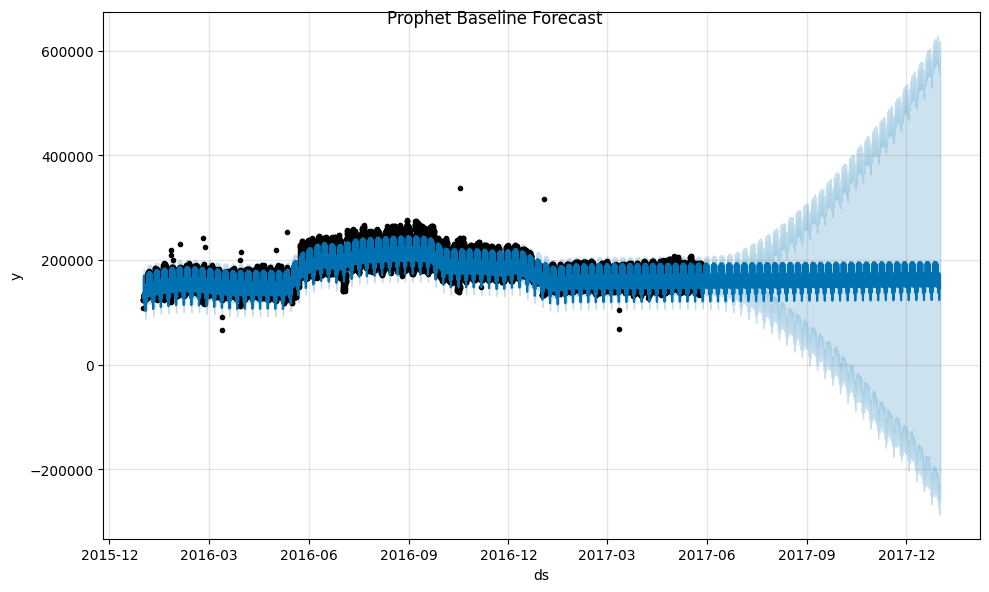

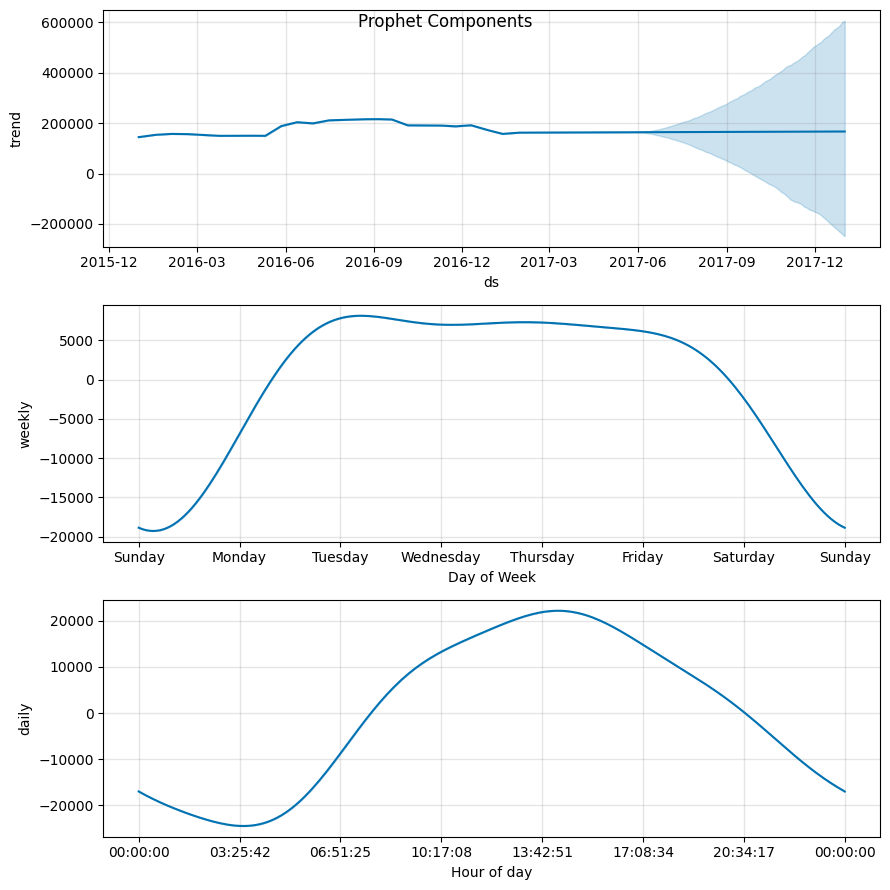

In [18]:
model_base = Prophet()
model_base.fit(train_p)

future_base = model_base.make_future_dataframe(periods=len(test_p), freq='h')
forecast_base = model_base.predict(future_base)

pred_base = forecast_base['yhat'].iloc[split:].values
rmse_base = np.sqrt(mean_squared_error(test_p['y'], pred_base))
mae_base  = mean_absolute_error(test_p['y'], pred_base)
print(f"Baseline Prophet - RMSE: {rmse_base:.2f} | MAE: {mae_base:.2f}")

fig1 = model_base.plot(forecast_base)
fig1.suptitle('Prophet Baseline Forecast')

fig2 = model_base.plot_components(forecast_base)
fig2.suptitle('Prophet Components')

prophet_results = [{
    'model': 'Prophet baseline',
    'daily_seasonality': 'auto',
    'weekly_seasonality': 'auto',
    'yearly_seasonality': 'auto',
    'daily_fourier': '-',
    'weekly_fourier': '-',
    'holidays': 'No',
    'RMSE': round(rmse_base, 2),
    'MAE': round(mae_base, 2)
}]

Model ostvaruje bolje rezultate nego iti jedan ARIMA model, što je zadovoljavajuć rezultat. Vidi se jasan trend u tjednim i dnevnim kretanjima potrošnje, što je i ranije zaključeno.

## 6.2. Manualno postavljanje sezonalnosti

In [19]:
fourier_combos = [
    {'daily': 5,  'weekly': 3},
    {'daily': 10, 'weekly': 5},
    {'daily': 15, 'weekly': 10},
]

for combo in fourier_combos:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        seasonality_mode='multiplicative',
    )
    m.add_seasonality(name='daily', period=1, fourier_order=combo['daily'])
    m.add_seasonality(name='weekly', period=7, fourier_order=combo['weekly'])
    m.add_seasonality(name='yearly', period=365.25, fourier_order=10)
    m.fit(train_p)

    fc   = m.predict(test_p[['ds']])
    pred = fc['yhat'].values
    rmse = np.sqrt(mean_squared_error(test_p['y'], pred))
    mae  = mean_absolute_error(test_p['y'], pred)
    print(f"daily_fourier={combo['daily']}, weekly_fourier={combo['weekly']} — RMSE: {rmse:.2f} | MAE: {mae:.2f}")

17:37:24 - cmdstanpy - INFO - Chain [1] start processing
17:37:41 - cmdstanpy - INFO - Chain [1] done processing


daily_fourier=5, weekly_fourier=3 — RMSE: 42810.78 | MAE: 28746.80


17:37:43 - cmdstanpy - INFO - Chain [1] start processing
17:38:06 - cmdstanpy - INFO - Chain [1] done processing


daily_fourier=10, weekly_fourier=5 — RMSE: 40778.72 | MAE: 26624.89


17:38:08 - cmdstanpy - INFO - Chain [1] start processing
17:38:33 - cmdstanpy - INFO - Chain [1] done processing


daily_fourier=15, weekly_fourier=10 — RMSE: 36404.64 | MAE: 22981.55


17:38:36 - cmdstanpy - INFO - Chain [1] start processing
17:39:05 - cmdstanpy - INFO - Chain [1] done processing


Manual Prophet RMSE: 34066.39 | MAE: 21561.51


Text(0.5, 0.98, 'Manual Prophet Components')

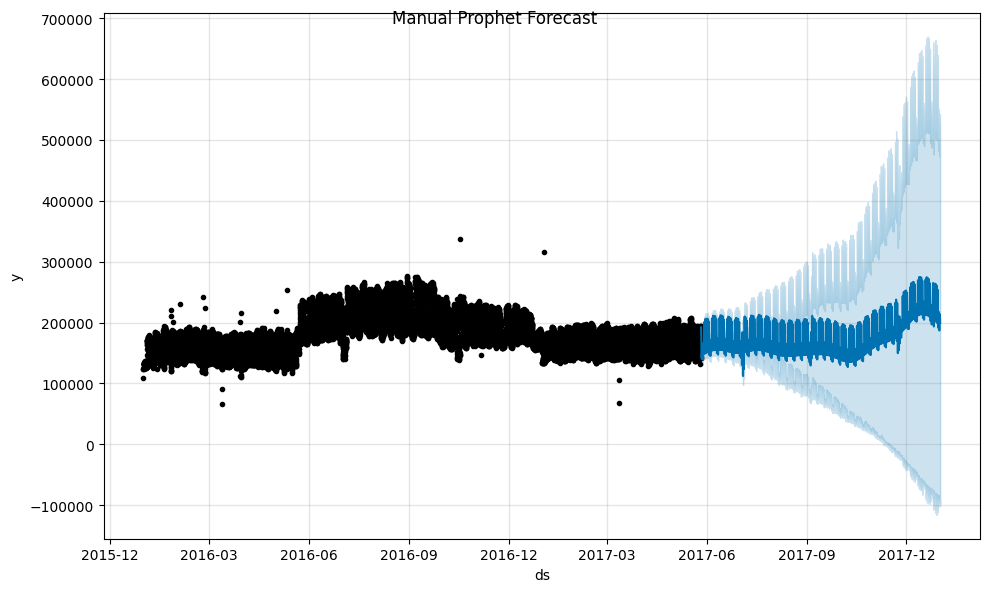

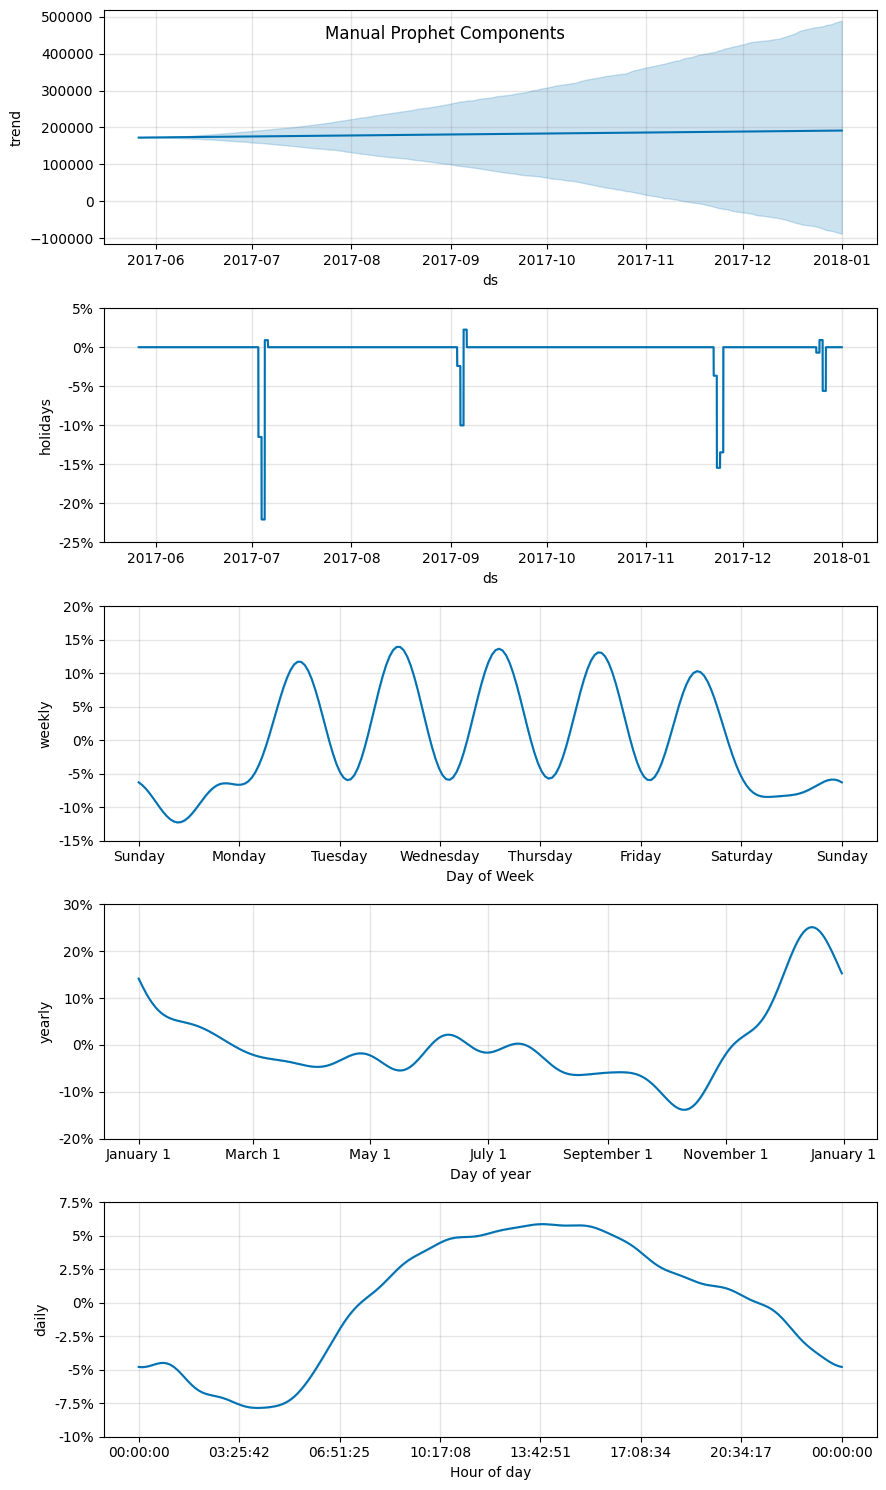

In [20]:
holidays = pd.DataFrame({
    'holiday': [
        'New Years Day',
        'New Years Day',
        'Independence Day',
        'Independence Day',
        'Thanksgiving',
        'Thanksgiving',
        'Christmas',
        'Christmas',
        'Labor Day',
        'Labor Day',
    ],
    'ds': pd.to_datetime([
        '2016-01-01', '2017-01-01',
        '2016-07-04', '2017-07-04',
        '2016-11-24', '2017-11-23',
        '2016-12-25', '2017-12-25',
        '2016-09-05', '2017-09-04',
    ]),
    'lower_window': -1,
    'upper_window': 1,
})

m_hol = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    seasonality_mode='multiplicative',
    holidays=holidays
)
m_hol.add_seasonality(name='daily', period=1, fourier_order=15)
m_hol.add_seasonality(name='weekly', period=7, fourier_order=10)
m_hol.add_seasonality(name='yearly', period=365.25, fourier_order=10)
m_hol.fit(train_p)

fc_hol = m_hol.predict(test_p[['ds']])
pred_hol = fc_hol['yhat'].values
rmse_hol = np.sqrt(mean_squared_error(test_p['y'], pred_hol))
mae_hol  = mean_absolute_error(test_p['y'], pred_hol)
print(f"Manual Prophet RMSE: {rmse_hol:.2f} | MAE: {mae_hol:.2f}")

fig3 = m_hol.plot(fc_hol)
fig3.suptitle('Manual Prophet Forecast')

fig4 = m_hol.plot_components(fc_hol)
fig4.suptitle('Manual Prophet Components')

Ovo je bio pokušaj manualnog postavljanja sezonalnosti, ali rezultat nije uspio doći blizu onom kad su sezonalnosti automatski postavljene. Razlog tome je to što Prophet automatski pronalazi optimalne parametre, dok manualni model to ne uspijeva.

# 7. Machine Learning Regression Models

## 7.1. Priprema skupa podataka

Prvi zadatak je izgraditi nove značajke koje će biti korištene za učenje modela. 

In [21]:
df_ml = df_total.copy().reset_index()

weather = df[df['meter'] == 0].groupby('timestamp').agg(
    air_temperature=('air_temperature', 'mean'),
    dew_temperature=('dew_temperature', 'mean'),
    wind_speed=('wind_speed', 'mean'),
    sea_level_pressure=('sea_level_pressure', 'mean'),
).reset_index()

df_ml = df_ml.merge(weather, on='timestamp', how='left')
df_ml = df_ml.sort_values('timestamp').reset_index(drop=True)

df_ml['hour'] = df_ml['timestamp'].dt.hour
df_ml['day_of_week'] = df_ml['timestamp'].dt.dayofweek
df_ml['month'] = df_ml['timestamp'].dt.month
df_ml['is_weekend']  = (df_ml['day_of_week'] >= 5).astype(int)
df_ml['quarter'] = df_ml['timestamp'].dt.quarter

df_ml['lag_1'] = df_ml['Total_Consumption'].shift(1)
df_ml['lag_2'] = df_ml['Total_Consumption'].shift(2)
df_ml['lag_3'] = df_ml['Total_Consumption'].shift(3)
df_ml['lag_24'] = df_ml['Total_Consumption'].shift(24)
df_ml['lag_48'] = df_ml['Total_Consumption'].shift(48)
df_ml['lag_168'] = df_ml['Total_Consumption'].shift(168)

df_ml['rolling_mean_24'] = df_ml['Total_Consumption'].shift(1).rolling(24).mean()
df_ml['rolling_std_24'] = df_ml['Total_Consumption'].shift(1).rolling(24).std()
df_ml['rolling_mean_168'] = df_ml['Total_Consumption'].shift(1).rolling(168).mean()
df_ml['rolling_max_24'] = df_ml['Total_Consumption'].shift(1).rolling(24).max()
df_ml['rolling_min_24'] = df_ml['Total_Consumption'].shift(1).rolling(24).min()

df_ml['target'] = df_ml['Total_Consumption'].shift(-1)

df_ml = df_ml.dropna().reset_index(drop=True)

print(f"Dataset shape: {df_ml.shape}")

Dataset shape: (17375, 23)


In [22]:
features = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'quarter',
    'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168',
    'rolling_max_24', 'rolling_min_24',
    'air_temperature', 'dew_temperature', 'wind_speed', 'sea_level_pressure'
]

X = df_ml[features]
y = df_ml['target']

n = len(df_ml)
split = int(n * 0.70)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 12162 | Test: 5213


## 7.3. Random Forest

RandomForest — RMSE: 7408.78 | MAE: 3640.67


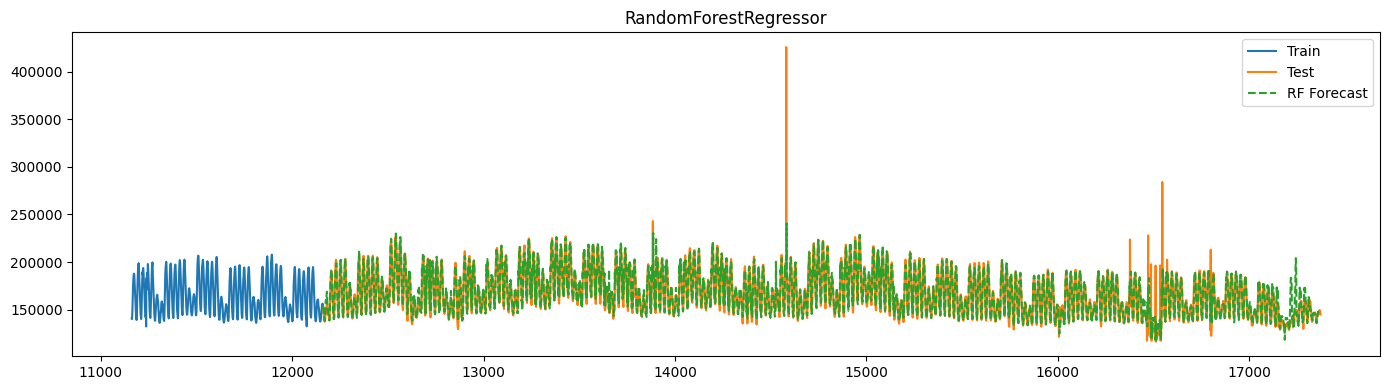

In [23]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf = mean_absolute_error(y_test, pred_rf)
print(f"RandomForest — RMSE: {rmse_rf:.2f} | MAE: {mae_rf:.2f}")

plt.figure(figsize=(14, 4))
plt.plot(y_train.index[-1000:], y_train.values[-1000:], label='Train')
plt.plot(y_test.index, y_test.values, label='Test')
plt.plot(y_test.index, pred_rf, linestyle='--', label='RF Forecast')
plt.title('RandomForestRegressor')
plt.legend()
plt.tight_layout()
plt.show()

Random Forest ostvario je novi najbolji rezultat - što je i donekle očekivano, s obzirom da svi raniji modeli rade isključivo s timestampom, dok Random Forest ima dosta različitih značajki.

## 7.4. XGBoost

XGBoost — RMSE: 11306.89 | MAE: 6208.98


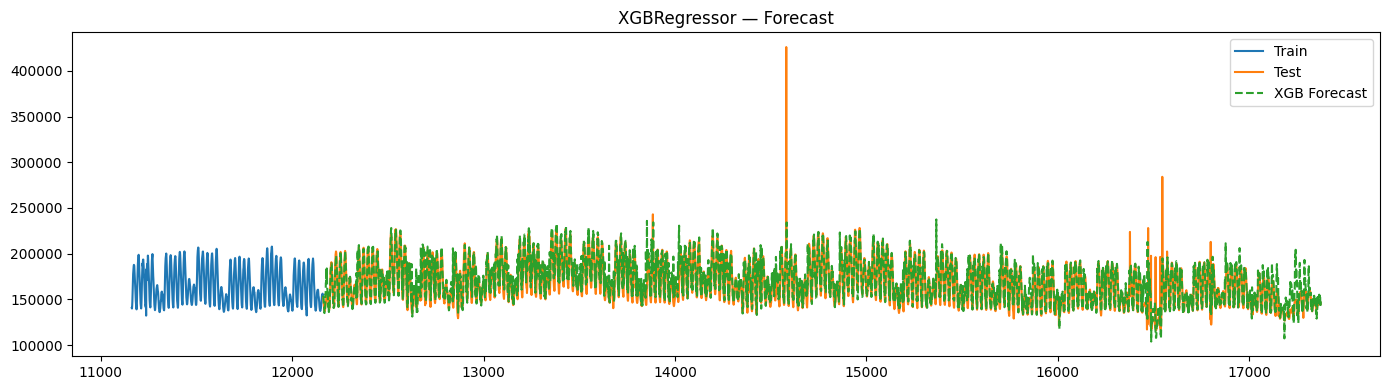

In [24]:
xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae_xgb = mean_absolute_error(y_test, pred_xgb)
print(f"XGBoost — RMSE: {rmse_xgb:.2f} | MAE: {mae_xgb:.2f}")

plt.figure(figsize=(14, 4))
plt.plot(y_train.index[-1000:], y_train.values[-1000:], label='Train')
plt.plot(y_test.index, y_test.values, label='Test')
plt.plot(y_test.index, pred_xgb, linestyle='--', label='XGB Forecast')
plt.title('XGBRegressor — Forecast')
plt.legend()
plt.tight_layout()
plt.show()

Za razliku od Random Foresta, XGBoost nije ostvario tako impresivan rezultat. Dosta slabije od Random Foresta, a tek nešto bolje od najboljeg modela Exponential Smoothinga.

# 8. Permutation feature importance 

U ovom dijelu provjerit ću koje značajke najviše doprinose predikciji modela.

## 8.1. Random Forest

In [25]:
pfi_rf = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

pfi_rf_df = pd.DataFrame({
    'feature': features,
    'importance': pfi_rf.importances_mean,
    'std': pfi_rf.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Random Forest — Permutation Feature Importance:")
print(pfi_rf_df.to_string(index=False))

Random Forest — Permutation Feature Importance:
           feature  importance      std
             lag_1    0.711810 0.015349
              hour    0.207742 0.004337
           lag_168    0.114071 0.006941
             lag_3    0.024850 0.001361
            lag_24    0.019406 0.001792
             lag_2    0.014991 0.000907
        is_weekend    0.008409 0.001318
   dew_temperature    0.007165 0.001628
       day_of_week    0.006711 0.000833
   rolling_mean_24    0.006388 0.001355
    rolling_min_24    0.005949 0.000558
            lag_48    0.003773 0.000400
   air_temperature    0.002832 0.001097
             month    0.002050 0.000209
    rolling_std_24    0.001768 0.000470
    rolling_max_24    0.001170 0.001576
           quarter    0.000867 0.000356
        wind_speed    0.000403 0.000081
sea_level_pressure   -0.000464 0.000165
  rolling_mean_168   -0.002968 0.000221


## 8.2. XGBoost

In [26]:
pfi_xgb = permutation_importance(
    xgb, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

pfi_xgb_df = pd.DataFrame({
    'feature': features,
    'importance': pfi_xgb.importances_mean,
    'std': pfi_xgb.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("XGBoost — Permutation Feature Importance:")
print(pfi_xgb_df.to_string(index=False))

XGBoost — Permutation Feature Importance:
           feature  importance      std
             lag_1    0.668378 0.011723
              hour    0.154060 0.006235
           lag_168    0.087870 0.005314
             lag_2    0.076408 0.003730
       day_of_week    0.058510 0.004189
   dew_temperature    0.047660 0.003055
    rolling_max_24    0.046521 0.002488
             lag_3    0.044757 0.002761
            lag_48    0.019481 0.002129
    rolling_min_24    0.017287 0.001300
   rolling_mean_24    0.012042 0.001064
sea_level_pressure    0.010195 0.002315
             month    0.009557 0.002642
            lag_24    0.005549 0.004278
    rolling_std_24    0.003371 0.002167
  rolling_mean_168    0.002883 0.001783
        wind_speed    0.000942 0.000485
        is_weekend    0.000000 0.000000
           quarter    0.000000 0.000000
   air_temperature   -0.003204 0.003863


## 8.3. Vizualna usporedba

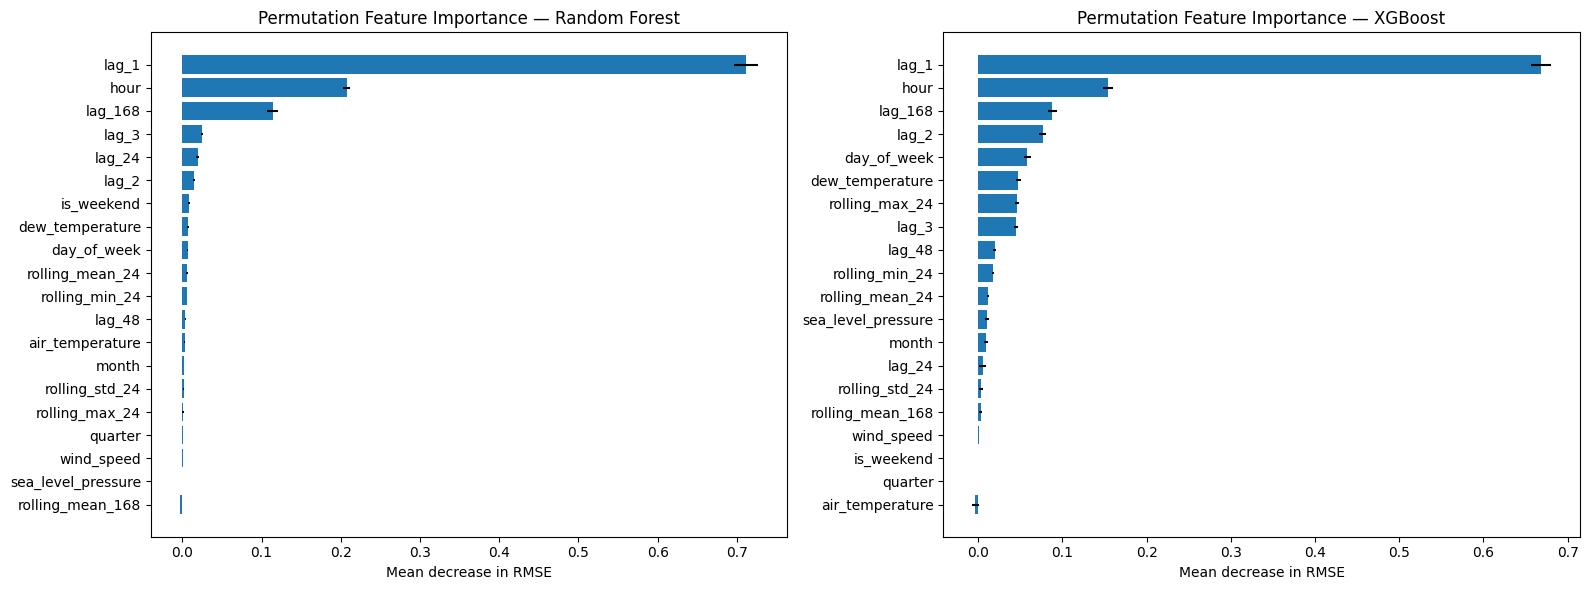

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.barh(pfi_rf_df['feature'], pfi_rf_df['importance'], xerr=pfi_rf_df['std'])
ax.set_title('Permutation Feature Importance — Random Forest')
ax.set_xlabel('Mean decrease in RMSE')
ax.invert_yaxis()

ax = axes[1]
ax.barh(pfi_xgb_df['feature'], pfi_xgb_df['importance'], xerr=pfi_xgb_df['std'])
ax.set_title('Permutation Feature Importance — XGBoost')
ax.set_xlabel('Mean decrease in RMSE')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Primjećujemo, iste značajke su najbitnije za oba modela. Uvjerljivo najvažnija jest značajka lag_1, koja govori o potrošnji u prethodnom satu. Bitne značajke su isto tako hour i lag_168. U Random Forest modelu ostale značajke nemaju veliku važnost, dok XGBoost ima još nekoliko značajki sa nezanemarivim doprinosom.

# 9. Dodatne usporedbe i vizualizacije

In [28]:
test_timestamps = df_ml['timestamp'].iloc[split:].values

results_df = pd.DataFrame({
    'timestamp': test_timestamps,
    'actual': y_test.values,
    'RF': pred_rf,
    'XGB': pred_xgb,
})
results_df['timestamp'] = pd.to_datetime(results_df['timestamp'])
results_df['hour'] = results_df['timestamp'].dt.hour
results_df['day_of_week'] = results_df['timestamp'].dt.dayofweek

results_df['abs_err_RF'] = np.abs(results_df['actual'] - results_df['RF'])
results_df['abs_err_XGB'] = np.abs(results_df['actual'] - results_df['XGB'])

results_df['resid_RF'] = results_df['actual'] - results_df['RF']
results_df['resid_XGB'] = results_df['actual'] - results_df['XGB']

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

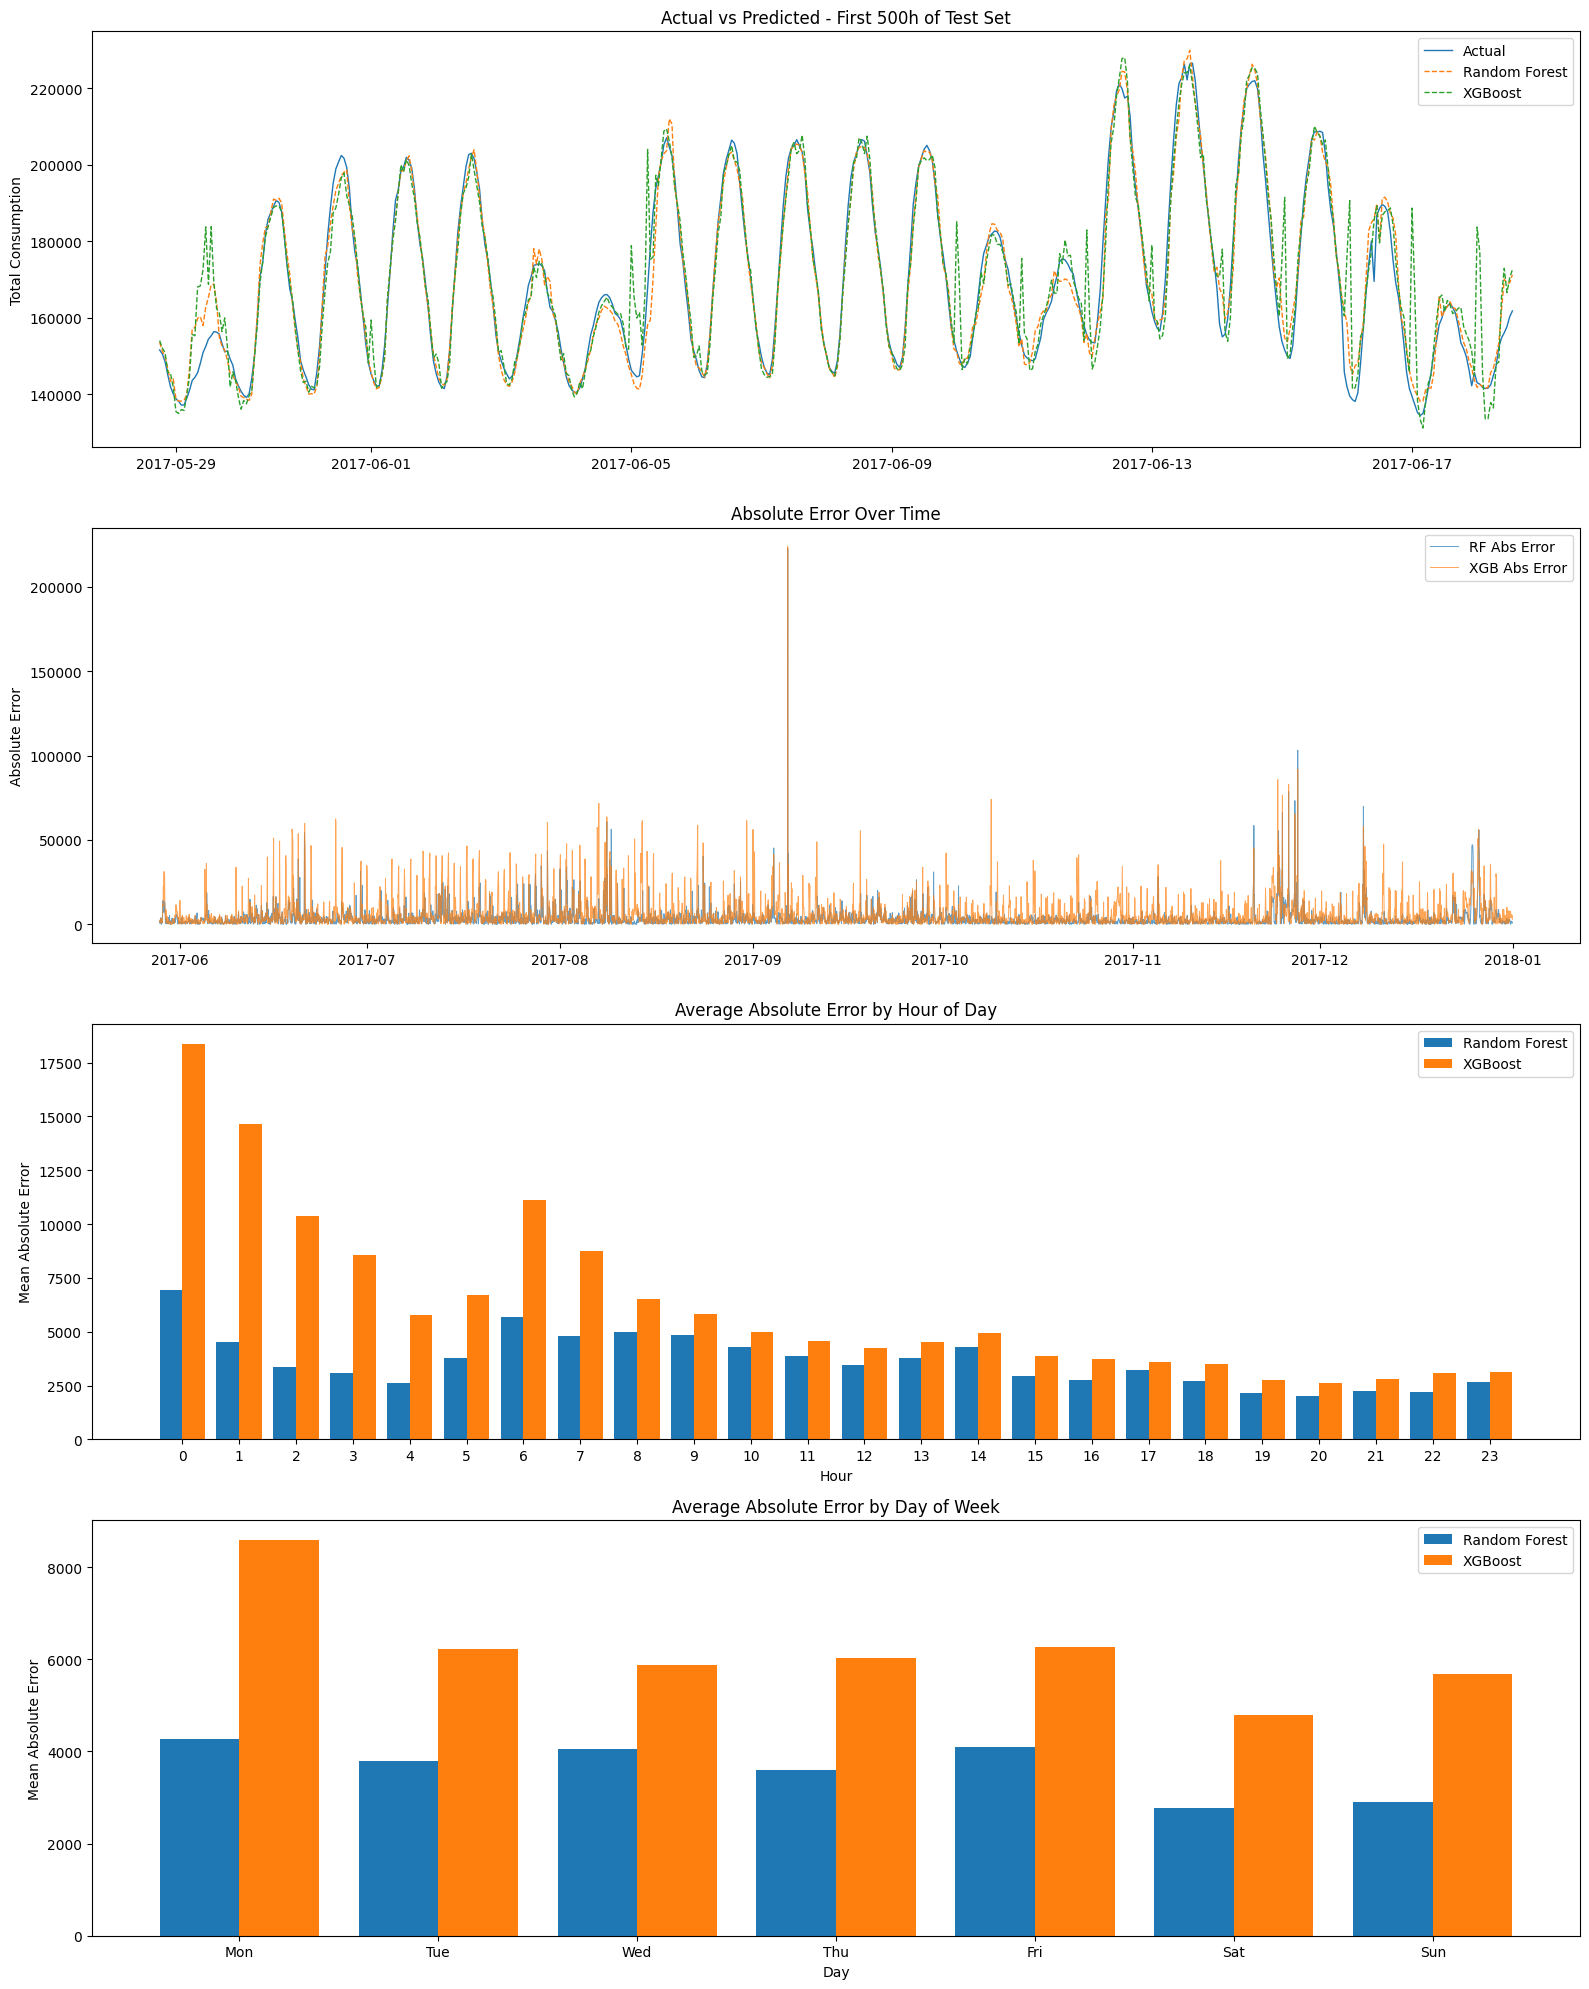

In [29]:
fig, axes = plt.subplots(4, 1, figsize=(16, 20))

ax = axes[0]
ax.plot(results_df['timestamp'].iloc[:500], results_df['actual'].iloc[:500],
        label='Actual', linewidth=1)
ax.plot(results_df['timestamp'].iloc[:500], results_df['RF'].iloc[:500],
        linestyle='--', linewidth=1, label='Random Forest')
ax.plot(results_df['timestamp'].iloc[:500], results_df['XGB'].iloc[:500],
        linestyle='--', linewidth=1, label='XGBoost')
ax.set_title('Actual vs Predicted - First 500h of Test Set')
ax.set_ylabel('Total Consumption')
ax.legend()

ax = axes[1]
ax.plot(results_df['timestamp'], results_df['abs_err_RF'],
        linewidth=0.7, alpha=0.7, label='RF Abs Error')
ax.plot(results_df['timestamp'], results_df['abs_err_XGB'],
        linewidth=0.7, alpha=0.7, label='XGB Abs Error')
ax.set_title('Absolute Error Over Time')
ax.set_ylabel('Absolute Error')
ax.legend()

ax = axes[2]
err_by_hour_rf  = results_df.groupby('hour')['abs_err_RF'].mean()
err_by_hour_xgb = results_df.groupby('hour')['abs_err_XGB'].mean()

x = np.arange(24)
width = 0.4
ax.bar(x - width/2, err_by_hour_rf.values,  width=width, label='Random Forest')
ax.bar(x + width/2, err_by_hour_xgb.values, width=width, label='XGBoost')
ax.set_title('Average Absolute Error by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Mean Absolute Error')
ax.set_xticks(x)
ax.legend()

ax = axes[3]
err_by_day_rf  = results_df.groupby('day_of_week')['abs_err_RF'].mean()
err_by_day_xgb = results_df.groupby('day_of_week')['abs_err_XGB'].mean()

x = np.arange(7)
ax.bar(x - width/2, err_by_day_rf.values,  width=width, label='Random Forest')
ax.bar(x + width/2, err_by_day_xgb.values, width=width, label='XGBoost')
ax.set_title('Average Absolute Error by Day of Week')
ax.set_xlabel('Day')
ax.set_ylabel('Mean Absolute Error')
ax.set_xticks(x)
ax.set_xticklabels(days)
ax.legend()

plt.tight_layout()
plt.show()

Kao i iz samih brojeva, i iz ovih vizualizacija se vidi da Random Forest daje bolje predikcije od XGBoosta. U svakom od grafova se vidi da je Random Forest točniji, u prvom grafu bolje prati kretanje ukupne potrošnje, a u trećem i četvrtom grafu ima manju grešku i to u svakom satu i svakom danu. XGBoost model najveće probleme ima u ranim satima (od 0 do 6 ujutro), kao što je najveća greška u ponedjeljak. S druge strane, Random Forest ima sličnu grešku tijekom više manje svih sati i svih dana u tjednu, što je zadovoljavajuće.

# 10. Zaključak i usporedni pregled modela

In [30]:
es_rmse = np.sqrt(mean_squared_error(test, pred_best))
es_mae = mean_absolute_error(test, pred_best)
es_params = f"trend={best['trend']}, seasonal={best['seasonal']}, period={best['period']}"

arima_models = [r for r in results if r['model'].startswith('ARIMA(')]
sarima_models = [r for r in results if r['model'].startswith('SARIMA')]
if sarima_models:
    arima_best = min(sarima_models, key=lambda x: x['RMSE'])
elif arima_models:
    arima_best = min(arima_models, key=lambda x: x['RMSE'])
else:
    arima_best = {'model': 'ARIMA', 'RMSE': np.nan, 'MAE': np.nan}

prophet_baseline_rmse = np.sqrt(mean_squared_error(test_p['y'], pred_base))
prophet_baseline_mae = mean_absolute_error(test_p['y'], pred_base)
prophet_params = 'daily_seasonality=auto, weekly_seasonality=auto, yearly_seasonality=auto'

summary_df = pd.DataFrame([
    {
        'Model': 'Exponential Smoothing',
        'Parameters': es_params,
        'RMSE': round(es_rmse, 2),
        'MAE': round(es_mae, 2)
    },
    {
        'Model': arima_best['model'],
        'Parameters': arima_best['model'],
        'RMSE': round(arima_best['RMSE'], 2),
        'MAE': round(arima_best['MAE'], 2)
    },
    {
        'Model': 'Prophet (baseline)',
        'Parameters': prophet_params,
        'RMSE': round(prophet_baseline_rmse, 2),
        'MAE': round(prophet_baseline_mae, 2)
    },
    {
        'Model': 'RandomForestRegressor',
        'Parameters': 'n_estimators=100, random_state=42, n_jobs=-1',
        'RMSE': round(rmse_rf, 2),
        'MAE': round(mae_rf, 2)
    },
    {
        'Model': 'XGBRegressor',
        'Parameters': 'n_estimators=100, random_state=42, n_jobs=-1, verbosity=0',
        'RMSE': round(rmse_xgb, 2),
        'MAE': round(mae_xgb, 2)
    }
])

summary_df = summary_df.sort_values('RMSE').reset_index(drop=True)
print(summary_df.to_string(index=False))

best_model = summary_df.loc[summary_df['RMSE'].idxmin()]

                     Model                                                               Parameters     RMSE      MAE
     RandomForestRegressor                             n_estimators=100, random_state=42, n_jobs=-1  7408.78  3640.67
              XGBRegressor                n_estimators=100, random_state=42, n_jobs=-1, verbosity=0 11306.89  6208.98
     Exponential Smoothing                                     trend=None, seasonal=add, period=168 13190.65  9696.84
        Prophet (baseline) daily_seasonality=auto, weekly_seasonality=auto, yearly_seasonality=auto 14521.92 11051.25
SARIMA(5, 1, 5)x(1,0,0,24)                                               SARIMA(5, 1, 5)x(1,0,0,24) 22394.50 18670.29


Model koji je dao najbolje rezultate bio je RandomForestRegressor, i to poprilično uvjerljivo.

Što se tiče interpretacije, najlakši za interpretirati je Exponential Smoothing, jer koristi samo trend i sezonalnost te se ponaša kao klasični vremenski serijski model.

S obzirom da je Random Forest ostvario uvjerljivo najbolji rezultat, preporučio bih njega za ovaj problem. Ukoliko je naglasak na interpretabilnosti, onda je i Exponential Smoothing dobar izbor jer je dao prihvatljiv rezultat, a lakše je razumljiv.

Neka od ograničenja ovog pristupa su to što je korišten samo jedan jednostavan train/test split umjesto vremenski prilagođene unakrsne validacije, model je treniran na podacima s jakom autokorelacijom, pa se može loše ponašati u slučaju promjene režima ili nepredviđenih prazničnih učinaka, vremenski značajke i vremenski uvjeti mogu imati nedostataka zbog nedostajućih vrijednosti ili buke u podacima, i na kraju, strojno učenje poput Random Foresta manje je transparentno od jednostavnih vremenskih modela.